<a href="https://colab.research.google.com/github/olawaleaboderin/AVCAD/blob/main/Exercise10_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix


In [16]:
# ── Load dataset ─────────────────────────────────────────────
df = pd.read_csv(
    'https://raw.githubusercontent.com/olawaleaboderin/greends-avcad-2026/main/examples/EFIplus_medit.zip',
    sep=";"
)
df.head()


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,Geomorph2,Geomorph3,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,Barriers_catchment_down,Barriers_river_segment_up,Barriers_river_segment_down,Barriers_number_river_segment_up,Barriers_number_river_segment_down,Barriers_distance_river_segment_up,Barriers_distance_river_segment_down,Impoundment,Hydropeaking,Water_abstraction,Hydro_mod,Temperature_impact,Velocity_increase,Reservoir_flushing,Sedimentation,Channelisation,Cross_sec,Instream_habitat,Riparian_vegetation,Embankment,Floodprotection,Floodplain,Toxic_substances,Acidification,Water_quality_index,Eutrophication,Organic_pollution,Organic_siltation,Sum of Run1_number_all,Total_sp,Abramis brama,Achondrostoma arcasii,Achondrostoma occidentale,Achondrostoma oligolepis,Acipenser naccarii,Alburnoides bipunctatus,Alburnus albidus,Alburnus alburnus,Alosa alosa,Alosa fallax,Ameiurus melas,Anaecypris hispanica,Anguilla anguilla,Atherina boyeri,Australoheros facetus,Barbatula barbatula,Barbatula quignardi,Barbus barbus,Barbus bocagei,Barbus comizo,Barbus graellsii,Barbus haasi,Barbus meridionalis,Barbus microcephalus,Barbus plebejus,Barbus sclateri,Barbus tyberinus,Blicca bjoerkna,Carassius auratus,Carassius carassius,Chelon labrosus,Chondrostoma genei,Chondrostoma nasus,Chondrostoma soetta,Chondrostoma toxostoma,Cobitis calderoni,Cobitis paludica,Cobitis taenia,Cottus gobio,Cottus hispaniolensis,Cyprinus carpio,Dicentrarchus labrax,Esox lucius,Gambusia affinis,Gambusia holbrooki,Gasterosteus aculeatus,Gasterosteus gymnurus,Gobio gobio,Gobio lozanoi,Gymnocephalus cernuus,Hypophthalmichthys molitrix,Iberochondrostoma almacai,Iberochondrostoma lemmingii,Iberochondrostoma lusitanicum,Lampetra fluviatilis,Lampetra planeri,Lepomis gibbosus,Leuciscus cephalus,Leuciscus leuciscus,Leuciscus lucumonis,Leuciscus souffia,Liza aurata,Liza ramada,Luciobarbus guiraonis,Micropterus salmoides,Mugil cephalus,Oncorhynchus mykiss,Pachychilon pictum,Padogobius martensii,Padogobius nigricans,Parachondrostoma arrigonis,Parachondrostoma miegii,Parachondrostoma turiense,Perca fluviatilis,Petromyzon marinus,Phoxinus bigerri,Phoxinus phoxinus,Platichthys flesus,Pseudochondrostoma duriense,Pseudochondrostoma polylepis,Pseudochondrostoma willkommii,Pseudorasbora parva,Rhodeus amarus,Rutilus aula,Rutilus rubilio,Rutilus rutilus,Salaria fluviatilis,Salmo salar,Salmo trutta fario,Salmo trutta macrostigma,Salvelinus fontinalis,Sander lucioperca,Scardinius erythrophthalmus,Silurus glanis,Squalius alburnoides,Squalius aradensis,Squalius carolitertii,Squalius laietanus,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,1,1,-0.047266,-1.039638,0.451016,Pluvial,Permanent,199,Siliceous,0.001,3.0,700.840807,522.071164,17.6,8.5,28.1,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,1.0,1.0,1.0,1,4.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,1,1,0.389648,-0.443332,0.489422,Groundwater,Permanent,1253,Calcareous,13.406,3.0,1603.519424,640.327779,9.3,0.6,18.9,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1

Preprocessing Stage:

In [17]:
# ── Environmental variables ─────
predictors = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
              'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

# ── Filter: Douro, Tejo, Mondego and Minho basins ────────────
basins = ['Douro', 'Tejo', 'Mondego', 'Minho']
df_basins = df[df['Catchment_name'].isin(basins)].copy()

print("Sites per basin:")
print(df_basins['Catchment_name'].value_counts())


Sites per basin:
Catchment_name
Minho      707
Tejo       509
Douro      401
Mondego     86
Name: count, dtype: int64


In [18]:
# ── Select predictors and drop NAs ───────────────────────────
df_clean = df_basins[predictors + ['Catchment_name']].dropna()
X        = df_clean[predictors].values
y        = df_clean['Catchment_name'].values

print(f"\nFinal dataset: {X.shape[0]} sites × {X.shape[1]} variables")

# ── Standardise ───────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Colour palette for the 4 basins
palette    = {'Douro': 'steelblue', 'Tejo': 'coral',
              'Mondego': 'seagreen', 'Minho': 'mediumpurple'}
basin_list = basins


Final dataset: 1681 sites × 7 variables


## Question 1: Run a PCA based on quantitative environmental variables (see previous exercise), using sites from the Douro, Tejo, Mondego and Minho basins. Produce a biplot with ‘Catchment_name’ as a grouping variable.

**AI Prompt Used:** *Run a PCA on the seven standardised quantitative environmental variables (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul). Produce a scree plot showing individual and cumulative explained variance. Produce a biplot projecting sites on PC1 and PC2, coloured by Catchment_name, with arrows showing the contribution of each environmental variable. Create a single combined table containing PCA loadings together with explained variance (%), cumulative variance (%), and eigenvalues for all principal components. Ensure all PCs (PC1–PC7) are displayed continuously in one table.*


PCA


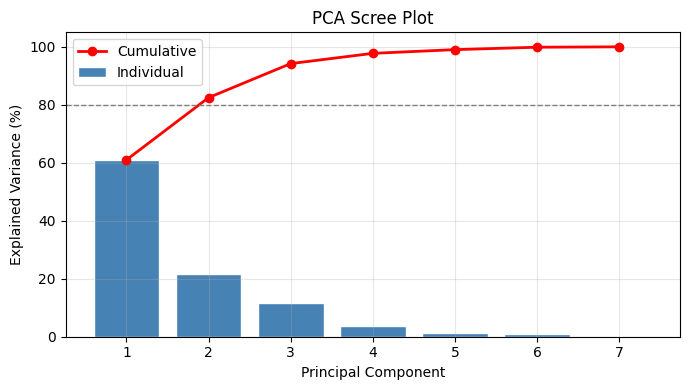

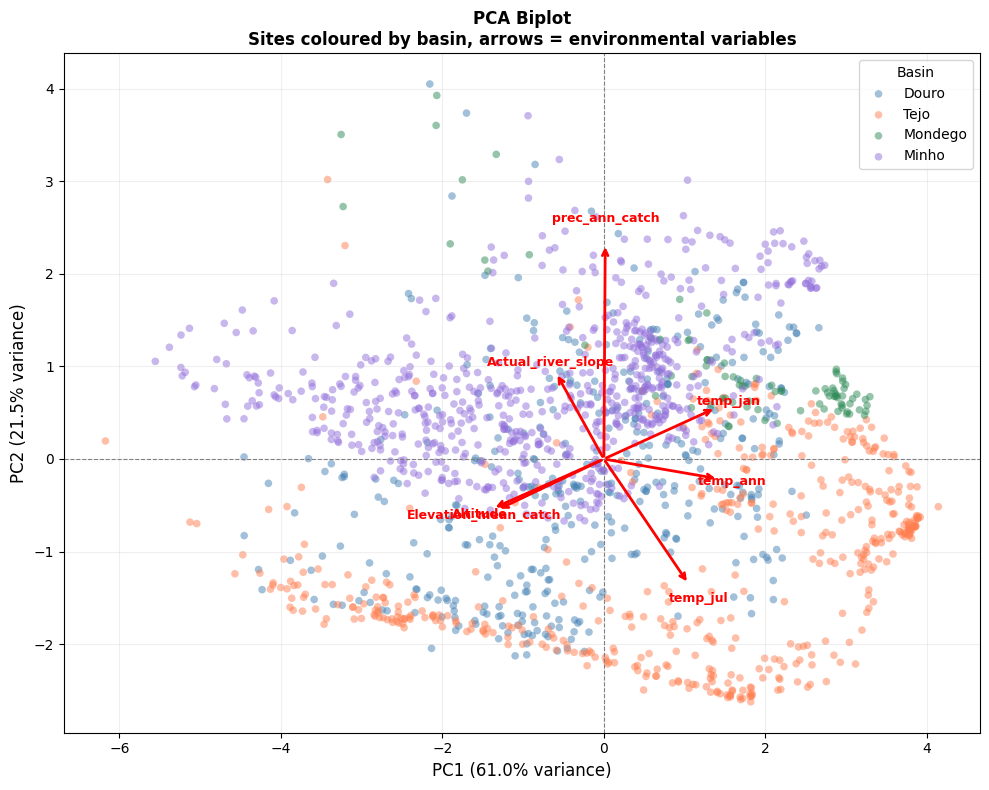


PCA Summary + Loadings:
                            PC1     PC2     PC3     PC4     PC5     PC6      PC7
Altitude                 -0.458  -0.178  -0.015  -0.011   0.656   0.556    0.139
Actual_river_slope       -0.197   0.310   0.911  -0.186  -0.017  -0.025    0.008
Elevation_mean_catch     -0.440  -0.183   0.083   0.577  -0.587   0.296   -0.046
prec_ann_catch            0.006   0.773  -0.144   0.558   0.260  -0.045   -0.004
temp_ann                  0.472  -0.071   0.163   0.190  -0.061   0.245    0.803
temp_jan                  0.462   0.184   0.031  -0.134  -0.136   0.712   -0.457
temp_jul                  0.349  -0.449   0.339   0.517   0.369  -0.185   -0.352
Explained Variance (%)   60.994  21.480  11.742   3.535   1.280   0.832    0.136
Cumulative Variance (%)  60.994  82.475  94.216  97.751  99.032  99.864  100.000
Eigenvalue                4.272   1.505   0.822   0.248   0.090   0.058    0.010


In [19]:

print("\n" + "="*60)
print("PCA")
print("="*60)

# ── Run PCA ──────────────────────────────────────────────────
pca        = PCA()
X_pca      = pca.fit_transform(X_scaled)

# Variance statistics
exp_var      = pca.explained_variance_ratio_ * 100
cum_var      = np.cumsum(exp_var)
eigenvalues  = pca.explained_variance_

# ── Scree Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(1, len(exp_var)+1),
       exp_var,
       color='steelblue',
       edgecolor='white',
       label='Individual')

ax.plot(range(1, len(exp_var)+1),
        cum_var,
        'ro-',
        linewidth=2,
        label='Cumulative')

ax.axhline(y=80,
           color='grey',
           linestyle='--',
           linewidth=1)

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Scree Plot')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── PCA Biplot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Plot sites coloured by basin
for basin in basin_list:
    mask = y == basin

    ax.scatter(X_pca[mask, 0],
               X_pca[mask, 1],
               color=palette[basin],
               label=basin,
               alpha=0.5,
               s=30,
               edgecolors='none')

# Plot variable arrows (loadings)
loadings = pca.components_.T
scale    = 3

for j, var in enumerate(predictors):

    ax.annotate(
        '',
        xy=(loadings[j, 0] * scale,
            loadings[j, 1] * scale),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle='->',
            color='red',
            lw=2
        )
    )

    ax.text(loadings[j, 0] * scale * 1.12,
            loadings[j, 1] * scale * 1.12,
            var,
            color='red',
            fontsize=9,
            fontweight='bold',
            ha='center',
            va='center')

ax.axhline(0,
           color='grey',
           linewidth=0.8,
           linestyle='--')

ax.axvline(0,
           color='grey',
           linewidth=0.8,
           linestyle='--')

ax.set_xlabel(f'PC1 ({exp_var[0]:.1f}% variance)',
              fontsize=12)

ax.set_ylabel(f'PC2 ({exp_var[1]:.1f}% variance)',
              fontsize=12)

ax.set_title(
    'PCA Biplot\n'
    'Sites coloured by basin, arrows = environmental variables',
    fontsize=12,
    fontweight='bold'
)

ax.legend(title='Basin', fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ── Combined PCA Summary + Loadings Table ────────────────────

# Create loadings dataframe
pca_table = pd.DataFrame(
    pca.components_.T,
    index=predictors,
    columns=[f'PC{i+1}' for i in range(len(predictors))]
)

# Add summary rows BELOW loadings
pca_table.loc['Explained Variance (%)']  = exp_var
pca_table.loc['Cumulative Variance (%)'] = cum_var
pca_table.loc['Eigenvalue']              = eigenvalues

# Round values
pca_table = pca_table.round(3)

# Display all columns continuously
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\nPCA Summary + Loadings:")
print(pca_table)

The PCA and biplot together demonstrate that the environmental variables effectively differentiate the four river basins through clear climatic and topographic gradients. The strong cumulative variance explained by PC1 and PC2 (82.5%) indicates that the reduced two-dimensional representation retains most of the environmental information contained in the dataset. The first principal component mainly represents a temperature–altitude gradient, separating warmer low-altitude catchments from cooler high-altitude ones, while the second component is strongly associated with annual precipitation. The spatial arrangement of the basins on the biplot suggests distinct environmental characteristics among regions: Tejo is associated with warmer conditions, Douro with cooler and higher-altitude environments, Minho with wetter and mountainous conditions, and Mondego with comparatively warm and humid environments. In addition, the close alignment of the temperature vectors confirms strong positive correlations among temperature variables, whereas the near-perpendicular orientation of precipitation relative to temperature suggests that precipitation varies largely independently from the temperature gradient.

## Question 2: Using the same data, run a PCoA and project the sites using the resulting first two axis. Use also the ‘Catchment_name’ as a grouping variable.

**AI Prompt used:** *Using the same standardised data from the Douro, Tejo, Mondego and Minho basins, run a PCoA based on a Euclidean distance matrix. Double centre the distance matrix, perform eigen decomposition, retain only positive eigenvalues and compute the PCoA scores. Plot the sites projected onto the first two PCoA axes, coloured by Catchment_name, and report the explained variance for each axis*


PCoA

PCoA explained variance:
  PCoA1: 60.99%
  PCoA2: 21.48%
  PCoA3: 11.74%
  PCoA4: 3.54%


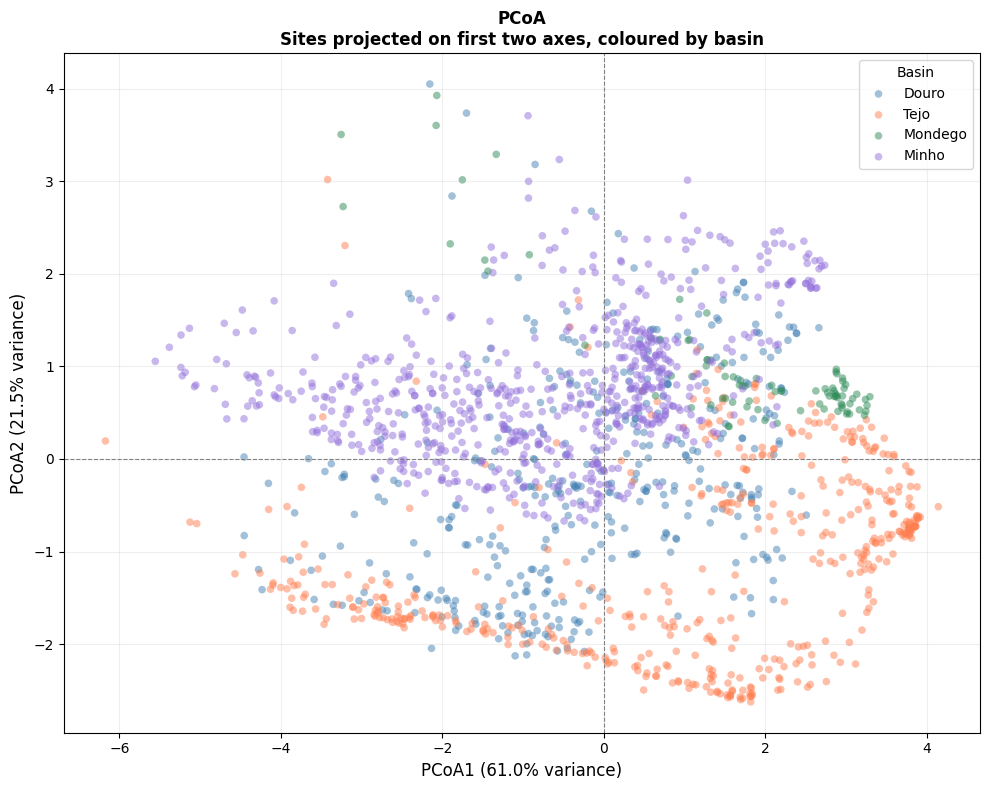

In [20]:
print("\n" + "="*60)
print("PCoA")
print("="*60)

# Compute euclidean distance matrix
dist_matrix = squareform(pdist(X_scaled, metric='euclidean'))
n           = dist_matrix.shape[0]

# Double centre the distance matrix
D  = dist_matrix ** 2
H  = np.eye(n) - np.ones((n, n)) / n
B  = -0.5 * H @ D @ H

# Eigen decomposition
eigenvalues, eigenvectors = eigh(B)

# Sort descending
idx         = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Keep only positive eigenvalues
pos_mask    = eigenvalues > 0
eigenvalues = eigenvalues[pos_mask]
eigenvectors = eigenvectors[:, pos_mask]

# PCoA scores
pcoa_scores = eigenvectors * np.sqrt(eigenvalues)

# Explained variance
exp_var_pcoa = eigenvalues / eigenvalues.sum() * 100
print("\nPCoA explained variance:")
for i in range(min(4, len(exp_var_pcoa))):
    print(f"  PCoA{i+1}: {exp_var_pcoa[i]:.2f}%")

# ── PCoA plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for basin in basin_list:
    mask = y == basin
    ax.scatter(pcoa_scores[mask, 0], pcoa_scores[mask, 1],
               color=palette[basin], label=basin,
               alpha=0.5, s=30, edgecolors='none')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel(f'PCoA1 ({exp_var_pcoa[0]:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PCoA2 ({exp_var_pcoa[1]:.1f}% variance)', fontsize=12)
ax.set_title('PCoA\nSites projected on first two axes, coloured by basin',
             fontsize=12, fontweight='bold')
ax.legend(title='Basin', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()



The PCoA based on Euclidean distances produced results almost identical to the PCA, with PCoA1 explaining 60.99% and PCoA2 explaining 21.48% of the total variance. This high similarity indicates that the environmental relationships among sites are highly linear and are well represented using Euclidean distances. Because PCA is mathematically equivalent to PCoA when Euclidean distance is applied to standardized continuous variables, the nearly identical variance explained and site configuration validate the consistency and robustness of the ordination analysis. The clustering patterns suggest that each basin occupies a characteristic environmental space shaped by differences in temperature, altitude, and precipitation, although the partial overlap between Douro and Tejo demonstrates that some environmental conditions are shared across basins. The tight clustering of Mondego sites indicates comparatively homogeneous environmental conditions within that basin, whereas the broader spread of Douro and Minho sites suggests greater environmental heterogeneity.

## Question 3:  Run a Linear Discriminant Analysis based on quantitative environmental variables (see previous exercises), using the Douro, Tejo, Mondego and Minho basins as the pre-determined groups. Produce a biplot with ‘Catchment_name’ as a grouping variable.

**AI Prompt used:** *Using the same standardised environmental variables from the Douro, Tejo, Mondego, and Minho basins, perform a Linear Discriminant Analysis (LDA) using Catchment_name as the pre-defined grouping variable. Produce an LDA biplot projecting sites onto the first two discriminant axes (LD1 and LD2), with sites coloured by basin, group centroids represented as stars, and arrows indicating the contribution of each environmental variable based on the LDA scalings. Report the percentage of explained variance for each discriminant axis, and evaluate classification performance using a classification report and confusion matrix.*


LINEAR DISCRIMINANT ANALYSIS

Explained variance by discriminant functions:
LD1: 90.62% (cumulative: 90.62%)
LD2: 5.73% (cumulative: 96.35%)

Cross-validated classification accuracy:
Mean Accuracy = 0.835
Standard Deviation = 0.023

Classification Report:
              precision    recall  f1-score   support

       Douro       0.72      0.61      0.66       395
        Tejo       0.87      0.97      0.92       707
     Mondego       0.70      0.66      0.68        86
       Minho       0.89      0.86      0.87       493

    accuracy                           0.84      1681
   macro avg       0.79      0.78      0.78      1681
weighted avg       0.83      0.84      0.83      1681


Confusion Matrix:
         Douro  Tejo  Mondego  Minho
Douro      241    49        6     99
Tejo        51   423       18      1
Mondego     24     4       57      1
Minho       17     0        1    689


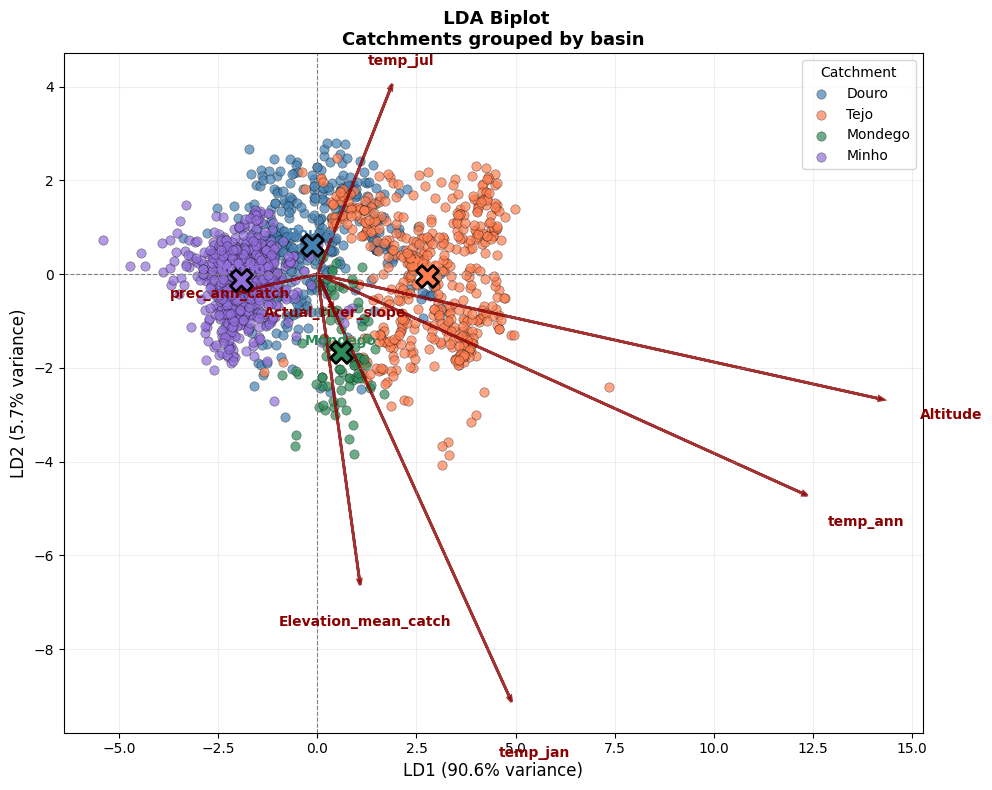


LDA Loadings:
                               LD1        LD2
Altitude                  3.573000  -0.669000
Actual_river_slope        0.101000  -0.186000
Elevation_mean_catch      0.270000  -1.658000
prec_ann_catch           -0.490000  -0.094000
temp_ann                  3.091000  -1.180000
temp_jan                  1.226000  -2.281000
temp_jul                  0.472000   1.014000
Explained Variance (%)   90.620956   5.732636
Cumulative Variance (%)  90.620956  96.353592


In [22]:

print("\n" + "="*60)
print("LINEAR DISCRIMINANT ANALYSIS")
print("="*60)

# ============================================================
# Define predictors and grouping variable
# ============================================================

# Standardized environmental variables
X = X_scaled

# Grouping variable (river basins)
y = df_clean['Catchment_name'].values

# ============================================================
# Fit LDA model
# ============================================================

# With 4 groups → maximum LD axes = 3
# We retain first two for visualization
lda = LDA(n_components=2)

# Fit model and obtain site scores
X_lda = lda.fit_transform(X, y)

# ============================================================
# Explained variance
# ============================================================

explained_var = lda.explained_variance_ratio_ * 100
cum_var = np.cumsum(explained_var)

print("\nExplained variance by discriminant functions:")

for i, (ev, cv) in enumerate(zip(explained_var, cum_var)):
    print(f"LD{i+1}: {ev:.2f}% "
          f"(cumulative: {cv:.2f}%)")

# ============================================================
# Create scores dataframe
# ============================================================

lda_scores_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2']
)

# ============================================================
# Cross-validation accuracy
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=1
)

scores = cross_val_score(
    lda,
    X,
    y,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

print(f"\nCross-validated classification accuracy:")
print(f"Mean Accuracy = {scores.mean():.3f}")
print(f"Standard Deviation = {scores.std():.3f}")

# ============================================================
# Predict classes (for confusion matrix/report)
# ============================================================

y_pred = lda.predict(X)

# ============================================================
# Classification report
# ============================================================

print("\nClassification Report:")
print(classification_report(
    y,
    y_pred,
    target_names=basin_list
))

# ============================================================
# Confusion matrix
# ============================================================

print("\nConfusion Matrix:")

cm = pd.DataFrame(
    confusion_matrix(y, y_pred, labels=basin_list),
    index=basin_list,
    columns=basin_list
)

print(cm)

# ============================================================
# LDA Biplot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# ============================================================
# Plot sample scores
# ============================================================

for basin in basin_list:

    mask = y == basin

    ax.scatter(
        lda_scores_df.loc[mask, 'LD1'],
        lda_scores_df.loc[mask, 'LD2'],
        color=palette[basin],
        label=basin,
        alpha=0.7,
        s=45,
        edgecolors='black',
        linewidth=0.3
    )

# ============================================================
# Plot centroids
# ============================================================

for basin in basin_list:

    mask = y == basin

    centroid_x = lda_scores_df.loc[mask, 'LD1'].mean()
    centroid_y = lda_scores_df.loc[mask, 'LD2'].mean()

    ax.scatter(
        centroid_x,
        centroid_y,
        color=palette[basin],
        s=250,
        edgecolor='black',
        linewidth=2,
        marker='X',
        zorder=5
    )

    ax.text(
        centroid_x,
        centroid_y + 0.15,
        basin,
        fontsize=10,
        fontweight='bold',
        color=palette[basin],
        ha='center'
    )

# ============================================================
# Plot variable arrows (LDA loadings)
# ============================================================

# Scaling factor for visibility
scale = 4

for i, var in enumerate(predictors):

    x_arrow = lda.scalings_[i, 0] * scale
    y_arrow = lda.scalings_[i, 1] * scale

    ax.arrow(
        0,
        0,
        x_arrow,
        y_arrow,
        color='darkred',
        alpha=0.8,
        head_width=0.08,
        linewidth=2,
        length_includes_head=True
    )

    ax.text(
        x_arrow * 1.12,
        y_arrow * 1.12,
        var,
        color='darkred',
        fontsize=10,
        fontweight='bold',
        ha='center',
        va='center'
    )

# ============================================================
# Axis lines
# ============================================================

ax.axhline(
    0,
    color='grey',
    linestyle='--',
    linewidth=0.8
)

ax.axvline(
    0,
    color='grey',
    linestyle='--',
    linewidth=0.8
)

# ============================================================
# Labels and formatting
# ============================================================

ax.set_xlabel(
    f'LD1 ({explained_var[0]:.1f}% variance)',
    fontsize=12
)

ax.set_ylabel(
    f'LD2 ({explained_var[1]:.1f}% variance)',
    fontsize=12
)

ax.set_title(
    ' LDA Biplot\n'
    'Catchments grouped by basin',
    fontsize=13,
    fontweight='bold'
)

ax.legend(
    title='Catchment',
    fontsize=10
)

ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ============================================================
# LDA loadings table
# ============================================================

lda_loadings = pd.DataFrame(
    lda.scalings_[:, :2],
    index=predictors,
    columns=['LD1', 'LD2']
).round(3)

# Add explained variance
lda_loadings.loc['Explained Variance (%)'] = explained_var
lda_loadings.loc['Cumulative Variance (%)'] = cum_var

print("\nLDA Loadings:")
print(lda_loadings)

The Linear Discriminant Analysis indicates that the Douro, Tejo, Mondego, and Minho basins are strongly differentiated by their environmental characteristics, with the first two discriminant axes explaining nearly all between-group variation (96.4%). The dominance of LD1 (90.6%) suggests that broad climatic and topographic gradients, particularly altitude and annual temperature, are the primary factors structuring basin differences, separating the warmer and lower-altitude Tejo catchments from the cooler and wetter Minho environments. LD2 captures more subtle variation associated with elevation and seasonal temperature dynamics, highlighting the distinct environmental profile of the Mondego basin relative to the other systems.
The classification report indicates an overall accuracy of 84%, suggesting that environmental variables alone are sufficient to distinguish most basin groups. However, the confusion observed between Douro and Minho, and between Mondego and Douro, suggests some overlap in environmental conditions among neighbouring basins. The cross-validated mean accuracy of 83.5% further confirms that the model generalises well and shows little evidence of overfitting.